# 🎬 Movie Dataset — Cleaning & Exploratory Analysis
**Dataset:** TMDB Movies (9,827 movies)
**Goal:** Clean the data, fix quality issues, and prepare it for SQL + Power BI dashboarding.

**Author:** Ipshita Verma


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('mymoviedb.csv', lineterminator='\n')
print("Shape:", df.shape)
df.head()

Shape: (9827, 9)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


## 2. Data Quality Check — Finding Problems

Before cleaning, let's identify what's wrong with the raw data.

In [3]:
print("Missing values:\n", df.isnull().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("\nDuplicate titles (different movies, same name):", df['Title'].duplicated().sum())

Missing values:
 Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64

Exact duplicate rows: 0

Duplicate titles (different movies, same name): 314


In [4]:
# Movies with 0 rating AND 0 votes = essentially "unrated" placeholder entries
unrated = ((df['Vote_Average'] == 0) & (df['Vote_Count'] == 0)).sum()
print(f"Unrated movies (Vote_Average=0 & Vote_Count=0): {unrated}")

# Genre column is multi-valued (comma-separated) -- a data quality issue for analysis
print("\nSample Genre values (notice multiple genres in one cell):")
print(df['Genre'].head(5).tolist())

# Language is a raw ISO code, not human-readable
print("\nSample Original_Language values:", df['Original_Language'].unique()[:10])

Unrated movies (Vote_Average=0 & Vote_Count=0): 100

Sample Genre values (notice multiple genres in one cell):
['Action, Adventure, Science Fiction', 'Crime, Mystery, Thriller', 'Thriller', 'Animation, Comedy, Family, Fantasy', 'Action, Adventure, Thriller, War']

Sample Original_Language values: <StringArray>
['en', 'ja', 'fr', 'hi', 'es', 'ru', 'de', 'th', 'ko', 'tr']
Length: 10, dtype: str


**Problems found:**
1. `Release_Date` is a string, not a proper date → can't extract year/month directly
2. `Genre` is comma-separated (multi-valued) → genre-wise counting will be wrong unless split
3. 100 movies have `Vote_Average = 0` and `Vote_Count = 0` → these are unrated, not "bad movies" — must flag separately so they don't skew average rating
4. `Original_Language` uses ISO codes (`en`, `ja`, `hi`...) → not dashboard-friendly
5. 314 duplicate titles (remakes, e.g. "365 Days" 2015 & 2020) → need Release_Year to tell them apart
6. No missing values and no exact duplicate rows — the base data itself is otherwise clean


## 3. Data Cleaning

### 3.1 Fix Release_Date → extract Year, Month, Decade

In [5]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Release_Year'] = df['Release_Date'].dt.year
df['Release_Month'] = df['Release_Date'].dt.month_name()
df['Release_Decade'] = (df['Release_Year'] // 10 * 10).astype('Int64').astype(str) + 's'
df[['Title','Release_Date','Release_Year','Release_Month','Release_Decade']].head()

,Title,Release_Date,Release_Year,Release_Month,Release_Decade
0,Spider-Man: No Way Home,2021-12-15,2021,December,2020s
1,The Batman,2022-03-01,2022,March,2020s
2,No Exit,2022-02-25,2022,February,2020s
3,Encanto,2021-11-24,2021,November,2020s
4,The King's Man,2021-12-22,2021,December,2020s


### 3.2 Flag unrated movies

In [6]:
df['Is_Rated'] = ~((df['Vote_Average'] == 0) & (df['Vote_Count'] == 0))
df['Is_Rated'].value_counts()

Is_Rated
True     9727
False     100
Name: count, dtype: int64

### 3.3 Map language codes to full names

In [7]:
# pip install pycountry --break-system-packages   (run once if not installed)
import pycountry

def get_lang_name(code):
    try:
        lang = pycountry.languages.get(alpha_2=code)
        return lang.name if lang else code
    except Exception:
        return code

lang_map = {c: get_lang_name(c) for c in df['Original_Language'].unique()}
df['Language_Name'] = df['Original_Language'].map(lang_map)
df[['Original_Language','Language_Name']].drop_duplicates().head(10)

,Original_Language,Language_Name
0,en,English
11,ja,Japanese
12,fr,French
18,hi,Hindi
35,es,Spanish
39,ru,Russian
61,de,German
79,th,Thai
84,ko,Korean
95,tr,Turkish


### 3.4 Handle multi-valued Genre column

In [8]:
df['Genre'] = df['Genre'].str.strip()
df['Primary_Genre'] = df['Genre'].str.split(',').str[0].str.strip()
df['Genre_Count'] = df['Genre'].str.split(',').apply(len)
df[['Title','Genre','Primary_Genre','Genre_Count']].head()

,Title,Genre,Primary_Genre,Genre_Count
0,Spider-Man: No Way Home,"Action, Adventure, Science Fiction",Action,3
1,The Batman,"Crime, Mystery, Thriller",Crime,3
2,No Exit,Thriller,Thriller,1
3,Encanto,"Animation, Comedy, Family, Fantasy",Animation,4
4,The King's Man,"Action, Adventure, Thriller, War",Action,4


### 3.5 Create Popularity Tier & Rating Category (useful for dashboard segmentation)

In [9]:
df['Popularity_Tier'] = pd.cut(
    df['Popularity'],
    bins=[-1, 20, 50, 100, float('inf')],
    labels=['Low', 'Medium', 'High', 'Viral']
)

def rating_category(row):
    if not row['Is_Rated']:
        return 'Unrated'
    elif row['Vote_Average'] >= 7.5:
        return 'Excellent'
    elif row['Vote_Average'] >= 6:
        return 'Good'
    elif row['Vote_Average'] >= 4:
        return 'Average'
    else:
        return 'Poor'

df['Rating_Category'] = df.apply(rating_category, axis=1)
df['Rating_Category'].value_counts()

Rating_Category
Good         5818
Average      2388
Excellent    1442
Unrated       100
Poor           79
Name: count, dtype: int64

### 3.6 Build a Genre bridge table (long format) — needed for accurate genre-wise SQL/Power BI analysis

In [10]:
genre_rows = []
for _, row in df.iterrows():
    for g in row['Genre'].split(','):
        genre_rows.append({'Title': row['Title'], 'Release_Year': row['Release_Year'], 'Genre': g.strip()})

df_genre_bridge = pd.DataFrame(genre_rows)
print("Bridge table shape:", df_genre_bridge.shape)
df_genre_bridge.head()

Bridge table shape: (25793, 3)


,Title,Release_Year,Genre
0,Spider-Man: No Way Home,2021,Action
1,Spider-Man: No Way Home,2021,Adventure
2,Spider-Man: No Way Home,2021,Science Fiction
3,The Batman,2022,Crime
4,The Batman,2022,Mystery


## 4. Save Cleaned Files (for SQL load & Power BI)

In [11]:
main_cols = ['Title', 'Release_Date', 'Release_Year', 'Release_Month', 'Release_Decade',
             'Popularity', 'Popularity_Tier', 'Vote_Count', 'Vote_Average', 'Is_Rated',
             'Rating_Category', 'Original_Language', 'Language_Name', 'Genre',
             'Primary_Genre', 'Genre_Count', 'Poster_Url']

df_clean = df[main_cols].copy()
df_clean.to_csv('movies_cleaned.csv', index=False)
df_genre_bridge.to_csv('movie_genre_bridge.csv', index=False)

print("Saved: movies_cleaned.csv", df_clean.shape)
print("Saved: movie_genre_bridge.csv", df_genre_bridge.shape)

Saved: movies_cleaned.csv (9827, 17)
Saved: movie_genre_bridge.csv (25793, 3)


## 5. Exploratory Data Analysis

### 5.1 Movies released per year

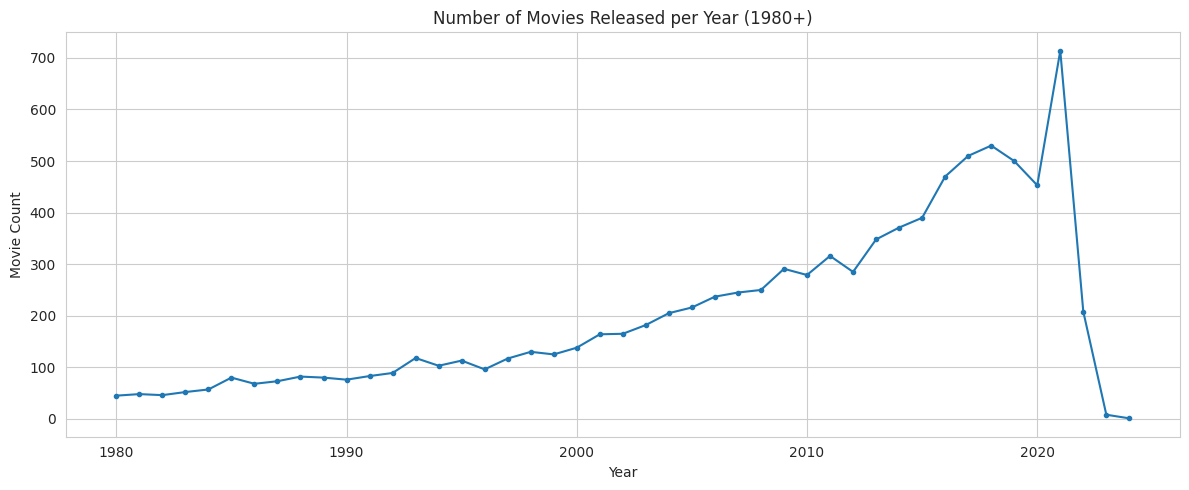

In [12]:
yearly = df_clean.dropna(subset=['Release_Year']).groupby('Release_Year').size()
yearly = yearly[yearly.index >= 1980]  # focus on modern era

plt.figure(figsize=(12,5))
yearly.plot(kind='line', marker='o', markersize=3)
plt.title('Number of Movies Released per Year (1980+)')
plt.xlabel('Year')
plt.ylabel('Movie Count')
plt.tight_layout()
plt.show()

### 5.2 Top 10 genres by movie count

/tmp/ipykernel_599/2068587304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


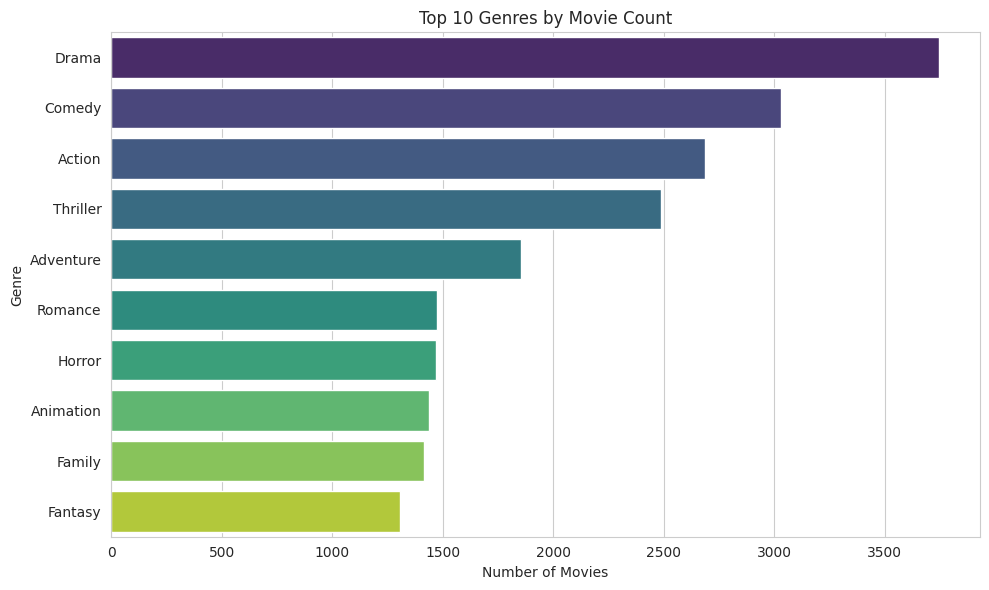

In [13]:
top_genres = df_genre_bridge['Genre'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Genres by Movie Count')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.show()

### 5.3 Rating distribution

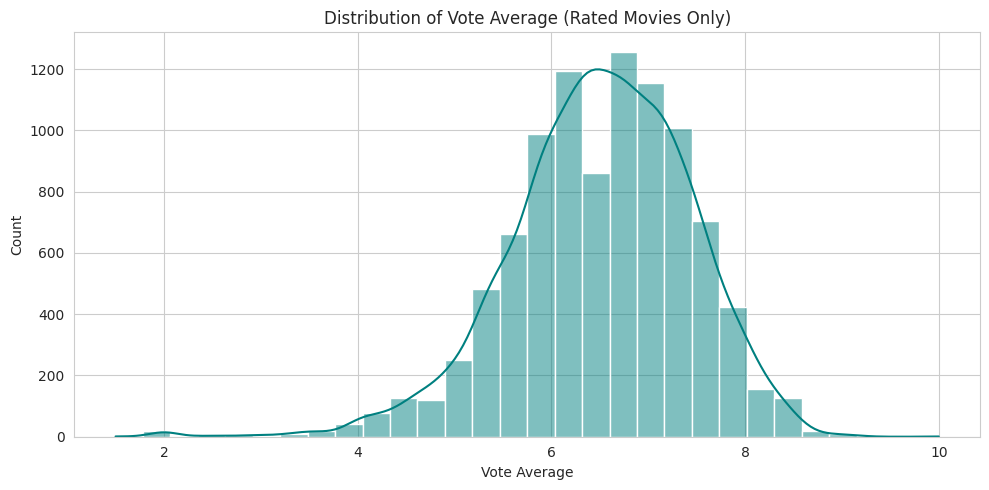

In [14]:
rated_only = df_clean[df_clean['Is_Rated']]

plt.figure(figsize=(10,5))
sns.histplot(rated_only['Vote_Average'], bins=30, kde=True, color='teal')
plt.title('Distribution of Vote Average (Rated Movies Only)')
plt.xlabel('Vote Average')
plt.tight_layout()
plt.show()

### 5.4 Genre vs Average Rating

/tmp/ipykernel_599/3097624754.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_by_genre.values, y=avg_by_genre.index, palette='mako')


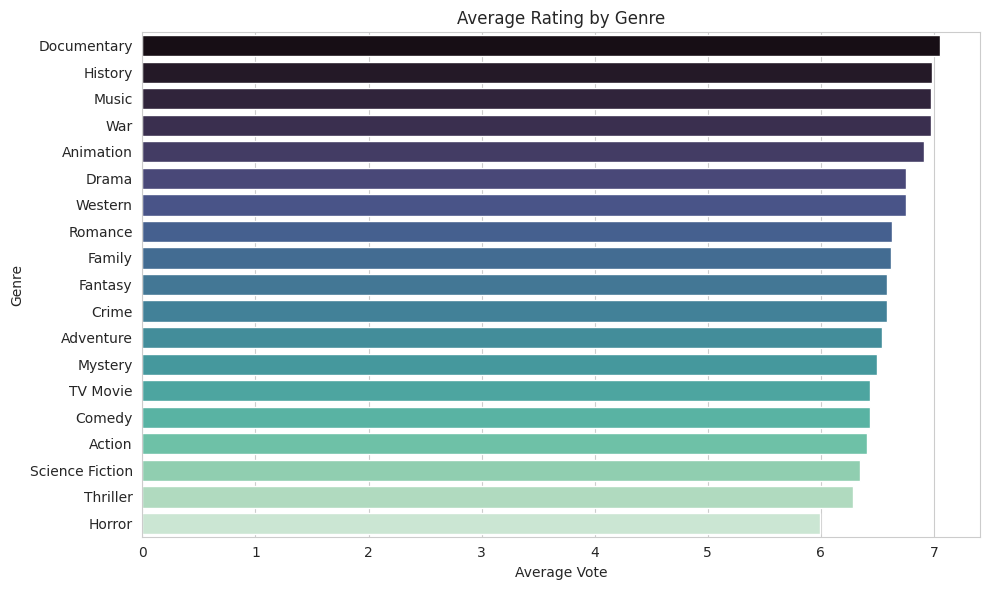

In [15]:
genre_rating = df_genre_bridge.merge(
    df_clean[['Title','Release_Year','Vote_Average','Is_Rated']],
    on=['Title','Release_Year']
)
genre_rating = genre_rating[genre_rating['Is_Rated']]

avg_by_genre = genre_rating.groupby('Genre')['Vote_Average'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_by_genre.values, y=avg_by_genre.index, palette='mako')
plt.title('Average Rating by Genre')
plt.xlabel('Average Vote')
plt.tight_layout()
plt.show()

### 5.5 Top 10 most popular movies

In [16]:
top_popular = df_clean.sort_values('Popularity', ascending=False).head(10)
top_popular[['Title','Release_Year','Popularity','Vote_Average','Primary_Genre']]

,Title,Release_Year,Popularity,Vote_Average,Primary_Genre
0,Spider-Man: No Way Home,2021,5083.954,8.3,Action
1,The Batman,2022,3827.658,8.1,Crime
2,No Exit,2022,2618.087,6.3,Thriller
3,Encanto,2021,2402.201,7.7,Animation
4,The King's Man,2021,1895.511,7.0,Action
5,The Commando,2022,1750.484,6.6,Action
6,Scream,2022,1675.161,6.8,Horror
7,Kimi,2022,1601.782,6.3,Thriller
8,Fistful of Vengeance,2022,1594.013,5.3,Action
9,Eternals,2021,1537.406,7.2,Science Fiction


### 5.6 Language distribution (top 10, excluding English for better visibility)

/tmp/ipykernel_599/2425425675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.values, y=lang_counts.index, palette='flare')


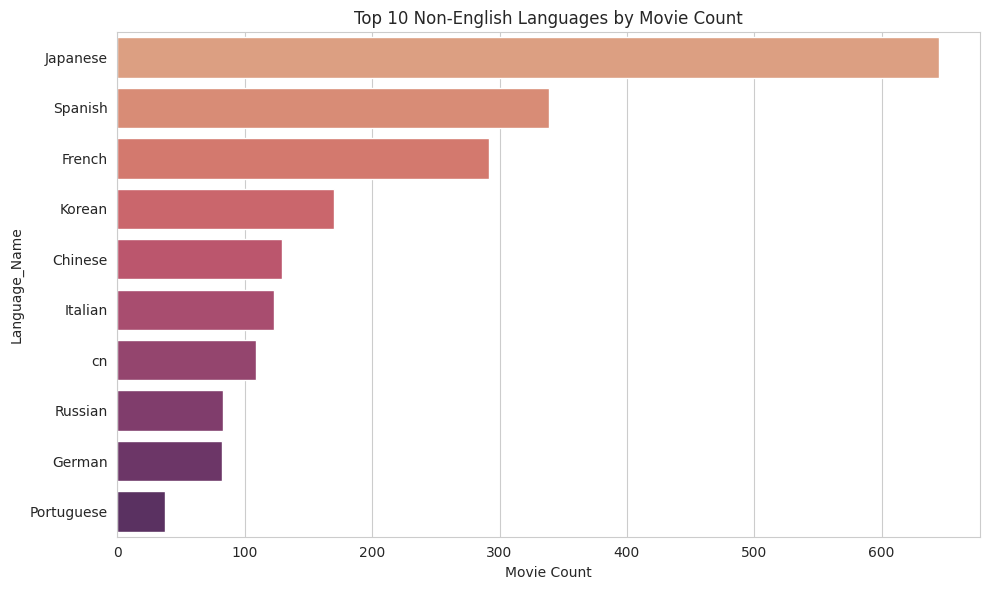

In [17]:
lang_counts = df_clean[df_clean['Language_Name'] != 'English']['Language_Name'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=lang_counts.values, y=lang_counts.index, palette='flare')
plt.title('Top 10 Non-English Languages by Movie Count')
plt.xlabel('Movie Count')
plt.tight_layout()
plt.show()

## 6. Summary

- Cleaned 9,827 movie records: fixed dates, split genres, mapped languages, flagged unrated entries
- Created a normalized genre bridge table (25,793 rows) for accurate multi-genre analysis
- Exported `movies_cleaned.csv` and `movie_genre_bridge.csv` — ready for PostgreSQL load and Power BI dashboarding

**Next steps:** Load both CSVs into PostgreSQL, run SQL aggregation queries, then build the Power BI dashboard.
